In [1]:
!pip install deap

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import numpy as np
import random
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from deap import base, creator, tools, algorithms
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [3]:
GA_CONFIG = {
    # Population parameters
    'POPULATION_SIZE': 100,
    'GENERATIONS': 50,
    'ELITISM_COUNT': 10,  # Number of best individuals to keep
    
    # Genetic operators probabilities
    'CROSSOVER_PROB': 0.7,
    'MUTATION_PROB': 0.3,
    'MUTATION_STRENGTH': 0.2,  # How much to change ingredient percentages
    
    # Selection parameters
    'TOURNAMENT_SIZE': 3,
    'SELECTION_PRESSURE': 0.7,  # Higher = more selective
    
    # Ingredient constraints
    'MIN_INGREDIENT_PCT': 0.01,  # Minimum 1% if ingredient is present
    'MAX_INGREDIENT_PCT': 0.5,   # Maximum 50% for any single ingredient
    'TOTAL_PCT_TARGET': 1.0,     # Total should sum to 100%
    'TOTAL_PCT_TOLERANCE': 0.1,  # Allow ±10% tolerance
    
    # Fitness weights
    'FLAVOR_WEIGHT': 0.8,        # Weight for flavor match
    'SIMPLICITY_WEIGHT': 0.2,    # Weight for fewer ingredients
    'PENALTY_STRENGTH': 0.5,     # How strongly to penalize bad solutions
    
    # Visualization
    'SAVE_PLOTS': True,
    'PLOT_EVERY_N_GENS': 5,
}

print("🎛️  GA Configuration Loaded:")
for key, value in GA_CONFIG.items():
    print(f"   {key:<25}: {value}")

🎛️  GA Configuration Loaded:
   POPULATION_SIZE          : 100
   GENERATIONS              : 50
   ELITISM_COUNT            : 10
   CROSSOVER_PROB           : 0.7
   MUTATION_PROB            : 0.3
   MUTATION_STRENGTH        : 0.2
   TOURNAMENT_SIZE          : 3
   SELECTION_PRESSURE       : 0.7
   MIN_INGREDIENT_PCT       : 0.01
   MAX_INGREDIENT_PCT       : 0.5
   TOTAL_PCT_TARGET         : 1.0
   TOTAL_PCT_TOLERANCE      : 0.1
   FLAVOR_WEIGHT            : 0.8
   SIMPLICITY_WEIGHT        : 0.2
   PENALTY_STRENGTH         : 0.5
   SAVE_PLOTS               : True
   PLOT_EVERY_N_GENS        : 5


In [6]:
try:
    with open('cocktail_flavor_predictor.pkl', 'rb') as f:
        model_data = pickle.load(f)
    
    taste_models = model_data['models']
    ingredient_columns = model_data['ingredient_columns']
    flavor_categories = model_data['flavor_categories']
    
    print(f"✅ Models loaded successfully!")
    print(f"   Number of ingredients: {len(ingredient_columns)}")
    print(f"   Flavors available: {', '.join(flavor_categories)}")
    
except FileNotFoundError:
    print("❌ Model file not found. Using dummy models for demonstration.")
    print("⚠️  Using dummy data - replace with actual trained models")
    
    # Create dummy data for demonstration
    ingredient_columns = [f'ingredient_{i}' for i in range(242)]
    flavor_categories = ['bittersweet', 'citrus', 'creamy', 'floral', 'fruity', 
                        'herbal', 'nutty', 'savoury', 'spicy', 'sweet']
    
    class DummyModel:
        def predict_proba(self, X):
            # Return random probabilities for demonstration
            return np.random.rand(len(X), 2)
    
    taste_models = {f: DummyModel() for f in flavor_categories}
    optimal_thresholds = {
        'bittersweet': 0.50,
        'citrus': 0.50,
        'creamy': 0.60,
        'floral': 0.90,
        'fruity': 0.60,
        'herbal': 0.55,
        'savoury': 0.80,
        'spicy': 0.75,
        'sweet': 0.80
    }

# Create ingredient index mapping for quick lookup
ingredient_to_index = {ing: idx for idx, ing in enumerate(ingredient_columns)}
print(f"\n📊 Ingredient mapping: {len(ingredient_to_index)} ingredients indexed")

✅ Models loaded successfully!
   Number of ingredients: 242
   Flavors available: bittersweet, citrus, creamy, floral, fruity, herbal, savoury, spicy, sweet

📊 Ingredient mapping: 242 ingredients indexed


In [13]:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))  # Maximize fitness
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

# 4.2 Define genetic operators
def create_individual(mandatory_indices=None, mandatory_pcts=None):
    """
    Create a random cocktail individual
    
    Parameters:
    -----------
    mandatory_indices: list of indices that must be present (can be empty)
    mandatory_pcts: list of percentages for mandatory ingredients (if None, random)
    
    Returns:
    --------
    Individual: List of 242 ingredient percentages
    """
    individual = [0.0] * len(ingredient_columns)
    
    # Handle mandatory ingredients
    if mandatory_indices:
        for i, idx in enumerate(mandatory_indices):
            if mandatory_pcts and i < len(mandatory_pcts):
                # Use provided percentages
                pct = mandatory_pcts[i]
            else:
                # Generate random percentage within bounds
                pct = random.uniform(GA_CONFIG['MIN_INGREDIENT_PCT'], 
                                   GA_CONFIG['MAX_INGREDIENT_PCT'])
            individual[idx] = pct
    
    # Add some random optional ingredients (0 to 10)
    num_optional = random.randint(0, 10)
    available_indices = [i for i in range(len(individual)) 
                        if i not in (mandatory_indices or [])]
    
    if available_indices and num_optional > 0:
        chosen_indices = random.sample(available_indices, 
                                      min(num_optional, len(available_indices)))
        for idx in chosen_indices:
            individual[idx] = random.uniform(GA_CONFIG['MIN_INGREDIENT_PCT'],
                                           GA_CONFIG['MAX_INGREDIENT_PCT'])
    
    # Normalize to approximately 100%
    normalize_individual(individual)
    
    return creator.Individual(individual)

def normalize_individual(individual):
    """Normalize ingredient percentages to sum to approximately 100%"""
    total = sum(individual)
    if total > 0:
        # Scale to target total percentage
        scale_factor = GA_CONFIG['TOTAL_PCT_TARGET'] / total
        for i in range(len(individual)):
            individual[i] *= scale_factor
    return individual

def evaluate_individual(individual, target_flavors, mandatory_indices=None):
    """
    Evaluate fitness of a cocktail recipe
    
    Parameters:
    -----------
    individual: List of ingredient percentages
    target_flavors: Dict of {flavor: weight} for multi-flavor targets
    mandatory_indices: Indices that must be non-zero (for penalty)
    
    Returns:
    --------
    fitness: Tuple with single fitness value
    """
    # Convert to numpy array for model prediction
    ingredient_vector = np.array(individual).reshape(1, -1)
    
    # Calculate flavor fitness
    flavor_fitness = 0
    total_weight = 0
    
    for flavor, weight in target_flavors.items():
        if flavor in taste_models:
            # Get probability from model
            proba = taste_models[flavor]['model'].predict_proba(ingredient_vector)[0][1]
            
            # Apply threshold
            threshold = optimal_thresholds.get(flavor, 0.5)
            if proba < threshold:
                proba *= GA_CONFIG['PENALTY_STRENGTH']  # Penalize below threshold
            
            flavor_fitness += proba * weight
            total_weight += weight
    
    if total_weight > 0:
        flavor_fitness /= total_weight
    
    # Calculate simplicity score (fewer ingredients = better)
    active_ingredients = sum(1 for x in individual if x > GA_CONFIG['MIN_INGREDIENT_PCT'])
    max_reasonable = 15  # More than 15 ingredients is unreasonable
    simplicity_score = max(0, max_reasonable - active_ingredients) / max_reasonable
    
    # Check mandatory ingredients constraint
    mandatory_penalty = 0
    if mandatory_indices:
        for idx in mandatory_indices:
            if individual[idx] < GA_CONFIG['MIN_INGREDIENT_PCT']:
                mandatory_penalty += 0.1  # Penalty for missing mandatory ingredient
    
    # Check total percentage constraint
    total_pct = sum(individual)
    total_penalty = abs(total_pct - GA_CONFIG['TOTAL_PCT_TARGET']) / GA_CONFIG['TOTAL_PCT_TOLERANCE']
    total_penalty = min(total_penalty, 1.0)  # Cap at 1.0
    
    # Combine scores
    fitness = (GA_CONFIG['FLAVOR_WEIGHT'] * flavor_fitness + 
               GA_CONFIG['SIMPLICITY_WEIGHT'] * simplicity_score - 
               mandatory_penalty - total_penalty)
    
    # Ensure fitness is non-negative
    fitness = max(0, fitness)
    
    return (fitness,)

def cxBlend(ind1, ind2):
    """Blend crossover - mixes ingredient percentages"""
    for i in range(len(ind1)):
        if random.random() < 0.5:
            # Blend the percentages
            alpha = random.uniform(-0.5, 1.5)  # Can extrapolate
            ind1[i] = alpha * ind1[i] + (1 - alpha) * ind2[i]
            ind2[i] = alpha * ind2[i] + (1 - alpha) * ind1[i]
    
    # Ensure values are within bounds
    for ind in [ind1, ind2]:
        for i in range(len(ind)):
            if ind[i] < 0:
                ind[i] = 0
            elif ind[i] > GA_CONFIG['MAX_INGREDIENT_PCT']:
                ind[i] = GA_CONFIG['MAX_INGREDIENT_PCT']
    
    normalize_individual(ind1)
    normalize_individual(ind2)
    
    return ind1, ind2

def mutGaussian(individual):
    """Gaussian mutation - adjust ingredient percentages"""
    for i in range(len(individual)):
        if random.random() < 0.1:  # Only mutate some ingredients
            if individual[i] > 0:  # Only mutate existing ingredients
                # Add Gaussian noise
                individual[i] += random.gauss(0, GA_CONFIG['MUTATION_STRENGTH'])
                # Ensure bounds
                individual[i] = max(0, min(GA_CONFIG['MAX_INGREDIENT_PCT'], individual[i]))
            elif random.random() < 0.05:  # Small chance to add new ingredient
                individual[i] = random.uniform(GA_CONFIG['MIN_INGREDIENT_PCT'],
                                             GA_CONFIG['MAX_INGREDIENT_PCT'])
    
    # Chance to remove an ingredient
    if random.random() < 0.1:
        active_indices = [i for i, val in enumerate(individual) 
                         if val > GA_CONFIG['MIN_INGREDIENT_PCT']]
        if active_indices:
            idx = random.choice(active_indices)
            individual[idx] = 0.0
    
    normalize_individual(individual)
    return individual,

# Register genetic operators
toolbox.register("individual", create_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", evaluate_individual)
toolbox.register("mate", cxBlend)
toolbox.register("mutate", mutGaussian)
toolbox.register("select", tools.selTournament, tournsize=GA_CONFIG['TOURNAMENT_SIZE'])

print("✅ DEAP setup complete!")
print(f"   Individual length: {len(ingredient_columns)} genes")
print(f"   Fitness weights: Flavor={GA_CONFIG['FLAVOR_WEIGHT']}, "
      f"Simplicity={GA_CONFIG['SIMPLICITY_WEIGHT']}")

✅ DEAP setup complete!
   Individual length: 242 genes
   Fitness weights: Flavor=0.8, Simplicity=0.2


In [14]:
def run_cocktail_ga(target_flavors, mandatory_ingredients=None, 
                   mandatory_percentages=None, verbose=True):
    """
    Run GA to optimize cocktail recipe for target flavors
    
    Parameters:
    -----------
    target_flavors: dict of {flavor: weight} e.g., {'citrus': 0.7, 'sweet': 0.3}
    mandatory_ingredients: list of ingredient names that must be included
    mandatory_percentages: optional list of percentages for mandatory ingredients
    verbose: whether to print progress
    
    Returns:
    --------
    best_individual: Optimized recipe
    log: Statistics from GA run
    """
    print("\n" + "=" * 80)
    print("COCKTAIL GENETIC ALGORITHM OPTIMIZATION")
    print("=" * 80)
    
    # Convert ingredient names to indices
    mandatory_indices = []
    if mandatory_ingredients:
        for ing in mandatory_ingredients:
            if ing in ingredient_to_index:
                mandatory_indices.append(ingredient_to_index[ing])
            else:
                print(f"⚠️  Warning: Mandatory ingredient '{ing}' not found in ingredient list")
    
    # Update individual creation to include mandatory ingredients
    def create_individual_with_mandatory():
        return create_individual(mandatory_indices, mandatory_percentages)
    
    toolbox.register("individual", create_individual_with_mandatory)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    
    # Create initial population
    pop = toolbox.population(n=GA_CONFIG['POPULATION_SIZE'])
    
    # Evaluate initial population
    fitnesses = []
    for ind in pop:
        # Wrap evaluate function to include target_flavors and mandatory_indices
        fitness = evaluate_individual(ind, target_flavors, mandatory_indices)
        ind.fitness.values = fitness
        fitnesses.append(fitness[0])
    
    if verbose:
        print(f"\n🎯 Target flavors: {target_flavors}")
        if mandatory_ingredients:
            print(f"🔧 Mandatory ingredients: {mandatory_ingredients}")
        print(f"👥 Initial population: {len(pop)} individuals")
        print(f"📊 Initial fitness - Min: {min(fitnesses):.3f}, "
              f"Avg: {np.mean(fitnesses):.3f}, Max: {max(fitnesses):.3f}")
    
    # Statistics setup
    stats = tools.Statistics(lambda ind: ind.fitness.values[0])
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)
    
    # Logbook for tracking
    logbook = tools.Logbook()
    logbook.header = ["gen", "nevals"] + stats.fields
    
    # Store best individuals across generations
    hall_of_fame = tools.HallOfFame(GA_CONFIG['ELITISM_COUNT'])
    
    # Evolution loop
    for gen in range(GA_CONFIG['GENERATIONS']):
        # Select next generation
        offspring = toolbox.select(pop, len(pop) - GA_CONFIG['ELITISM_COUNT'])
        
        # Clone selected individuals
        offspring = list(map(toolbox.clone, offspring))
        
        # Apply crossover and mutation
        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < GA_CONFIG['CROSSOVER_PROB']:
                toolbox.mate(child1, child2)
                del child1.fitness.values
                del child2.fitness.values
        
        for mutant in offspring:
            if random.random() < GA_CONFIG['MUTATION_PROB']:
                toolbox.mutate(mutant)
                del mutant.fitness.values
        
        # Evaluate offspring
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        for ind in invalid_ind:
            ind.fitness.values = evaluate_individual(ind, target_flavors, mandatory_indices)
        
        # Elitism: keep best individuals from previous generation
        pop = tools.selBest(pop, GA_CONFIG['ELITISM_COUNT']) + offspring
        
        # Update hall of fame
        hall_of_fame.update(pop)
        
        # Record statistics
        logbook.record(gen=gen, nevals=len(invalid_ind), **stats.compile(pop))
        
        if verbose and gen % GA_CONFIG['PLOT_EVERY_N_GENS'] == 0:
            print(f"   Generation {gen:3d}: Avg fitness = {logbook[gen]['avg']:.3f}, "
                  f"Best = {logbook[gen]['max']:.3f}")
    
    # Get best individual
    best_individual = tools.selBest(pop, 1)[0]
    
    if verbose:
        print(f"\n✅ Optimization complete after {GA_CONFIG['GENERATIONS']} generations!")
        print(f"🏆 Best fitness: {best_individual.fitness.values[0]:.3f}")
    
    return best_individual, logbook, hall_of_fame

In [15]:
def analyze_individual(individual, target_flavors, mandatory_indices=None):
    """
    Analyze and display details of a cocktail recipe
    """
    print("\n" + "=" * 80)
    print("COCKTAIL RECIPE ANALYSIS")
    print("=" * 80)
    
    # Get active ingredients
    active_ingredients = []
    for idx, pct in enumerate(individual):
        if pct > GA_CONFIG['MIN_INGREDIENT_PCT']:
            ingredient_name = ingredient_columns[idx]
            active_ingredients.append((ingredient_name, pct))
    
    # Sort by percentage (descending)
    active_ingredients.sort(key=lambda x: x[1], reverse=True)
    
    print(f"\n🍹 Cocktail Composition ({len(active_ingredients)} ingredients):")
    print("-" * 60)
    total_pct = 0
    for name, pct in active_ingredients:
        print(f"  {name:<40} : {pct*100:6.2f}%")
        total_pct += pct
    print(f"{'Total':<40} : {total_pct*100:6.2f}%")
    
    # Calculate flavor probabilities
    print(f"\n🎯 Flavor Profile:")
    print("-" * 60)
    ingredient_vector = np.array(individual).reshape(1, -1)
    
    for flavor, weight in target_flavors.items():
        if flavor in taste_models:
            proba = taste_models[flavor]['model'].predict_proba(ingredient_vector)[0][1]
            threshold = optimal_thresholds.get(flavor, 0.5)
            status = "✓ ABOVE" if proba >= threshold else "✗ BELOW"
            print(f"  {flavor:<12} : {proba:.3f} {status} threshold ({threshold:.2f})")
    
    # Check mandatory ingredients
    if mandatory_indices:
        print(f"\n🔧 Mandatory Ingredients Check:")
        print("-" * 60)
        for idx in mandatory_indices:
            ingredient_name = ingredient_columns[idx]
            pct = individual[idx]
            status = "✓ PRESENT" if pct > GA_CONFIG['MIN_INGREDIENT_PCT'] else "✗ MISSING"
            print(f"  {ingredient_name:<40} : {pct*100:6.2f}% ({status})")

def plot_evolution(logbook, target_flavors):
    """
    Plot evolution statistics
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot 1: Fitness over generations
    ax = axes[0, 0]
    gen = logbook.select("gen")
    ax.plot(gen, logbook.select("avg"), 'b-', label="Average Fitness", linewidth=2)
    ax.plot(gen, logbook.select("max"), 'r-', label="Best Fitness", linewidth=2)
    ax.fill_between(gen, logbook.select("min"), logbook.select("max"), 
                    alpha=0.2, color='gray', label="Range")
    ax.set_xlabel("Generation")
    ax.set_ylabel("Fitness")
    ax.set_title("Fitness Evolution")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Standard deviation
    ax = axes[0, 1]
    ax.plot(gen, logbook.select("std"), 'g-', linewidth=2)
    ax.set_xlabel("Generation")
    ax.set_ylabel("Standard Deviation")
    ax.set_title("Population Diversity")
    ax.grid(True, alpha=0.3)
    
    # Plot 3: Target flavor weights
    ax = axes[1, 0]
    flavors = list(target_flavors.keys())
    weights = list(target_flavors.values())
    colors = plt.cm.Set3(np.linspace(0, 1, len(flavors)))
    ax.bar(flavors, weights, color=colors)
    ax.set_xlabel("Flavor")
    ax.set_ylabel("Weight")
    ax.set_title("Target Flavor Weights")
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)
    
    # Plot 4: Fitness distribution in final generation
    ax = axes[1, 1]
    final_fitness = [ind.fitness.values[0] for ind in logbook.select("nevals")[-1]]
    ax.hist(final_fitness, bins=20, alpha=0.7, color='purple', edgecolor='black')
    ax.set_xlabel("Fitness")
    ax.set_ylabel("Count")
    ax.set_title("Final Generation Fitness Distribution")
    ax.grid(True, alpha=0.3)
    
    plt.suptitle(f"Cocktail GA Evolution: {', '.join(target_flavors.keys())}", 
                 fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
    
    if GA_CONFIG['SAVE_PLOTS']:
        plt.savefig('ga_evolution.png', dpi=150, bbox_inches='tight')
        print("📊 Evolution plots saved as 'ga_evolution.png'")

def plot_cocktail_recipe(individual, top_n=10):
    """
    Visualize the cocktail recipe as a bar chart
    """
    # Get top ingredients
    ingredient_data = []
    for idx, pct in enumerate(individual):
        if pct > GA_CONFIG['MIN_INGREDIENT_PCT']:
            ingredient_data.append((ingredient_columns[idx], pct))
    
    # Sort and take top N
    ingredient_data.sort(key=lambda x: x[1], reverse=True)
    top_ingredients = ingredient_data[:top_n]
    
    # Create plot
    plt.figure(figsize=(12, 6))
    names = [name for name, _ in top_ingredients]
    percentages = [pct * 100 for _, pct in top_ingredients]
    
    colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(top_ingredients)))
    bars = plt.barh(names, percentages, color=colors, edgecolor='black')
    
    plt.xlabel("Percentage (%)")
    plt.title(f"Top {top_n} Ingredients in Optimized Cocktail")
    plt.gca().invert_yaxis()  # Highest percentage at top
    
    # Add percentage labels
    for bar, pct in zip(bars, percentages):
        width = bar.get_width()
        plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{pct:.1f}%', va='center')
    
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()



🧪 TEST 1: Optimize for 'citrus' flavor
--------------------------------------------------------------------------------

COCKTAIL GENETIC ALGORITHM OPTIMIZATION

🎯 Target flavors: {'citrus': 1.0}
👥 Initial population: 100 individuals
📊 Initial fitness - Min: 0.000, Avg: 0.196, Max: 0.987
   Generation   0: Avg fitness = 0.341, Best = 0.987
   Generation   5: Avg fitness = 0.958, Best = 0.987
   Generation  10: Avg fitness = 0.980, Best = 0.987
   Generation  15: Avg fitness = 0.964, Best = 0.987
   Generation  20: Avg fitness = 0.966, Best = 0.987
   Generation  25: Avg fitness = 0.968, Best = 0.987
   Generation  30: Avg fitness = 0.970, Best = 0.987
   Generation  35: Avg fitness = 0.969, Best = 0.987
   Generation  40: Avg fitness = 0.970, Best = 0.987
   Generation  45: Avg fitness = 0.972, Best = 0.987

✅ Optimization complete after 50 generations!
🏆 Best fitness: 0.987

COCKTAIL RECIPE ANALYSIS

🍹 Cocktail Composition (1 ingredients):
--------------------------------------------

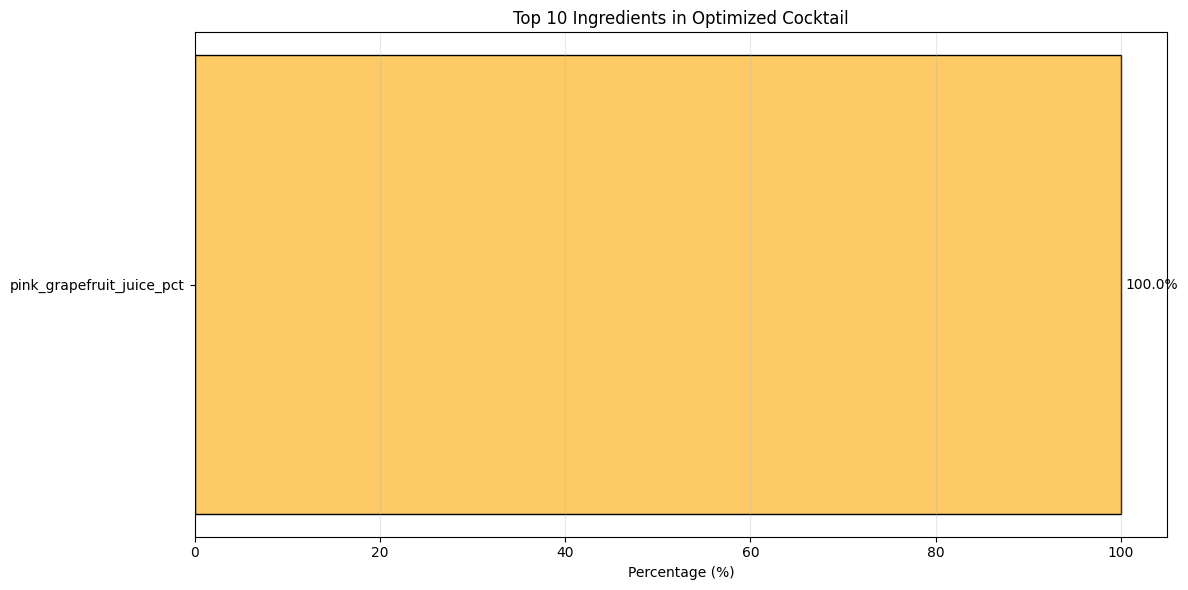


🧪 TEST 2: Optimize for 'sweet' and 'creamy' with gin as base
--------------------------------------------------------------------------------

COCKTAIL GENETIC ALGORITHM OPTIMIZATION

🎯 Target flavors: {'sweet': 0.6, 'creamy': 0.4}
🔧 Mandatory ingredients: ['gin_pct']
👥 Initial population: 100 individuals
📊 Initial fitness - Min: 0.114, Avg: 0.299, Max: 0.889
   Generation   0: Avg fitness = 0.418, Best = 0.889
   Generation   5: Avg fitness = 0.904, Best = 0.946
   Generation  10: Avg fitness = 0.938, Best = 0.973
   Generation  15: Avg fitness = 0.956, Best = 0.973
   Generation  20: Avg fitness = 0.961, Best = 0.973
   Generation  25: Avg fitness = 0.962, Best = 0.973
   Generation  30: Avg fitness = 0.957, Best = 0.973
   Generation  35: Avg fitness = 0.956, Best = 0.973
   Generation  40: Avg fitness = 0.946, Best = 0.973
   Generation  45: Avg fitness = 0.966, Best = 0.973

✅ Optimization complete after 50 generations!
🏆 Best fitness: 0.973

COCKTAIL RECIPE ANALYSIS

🍹 Cocktail 

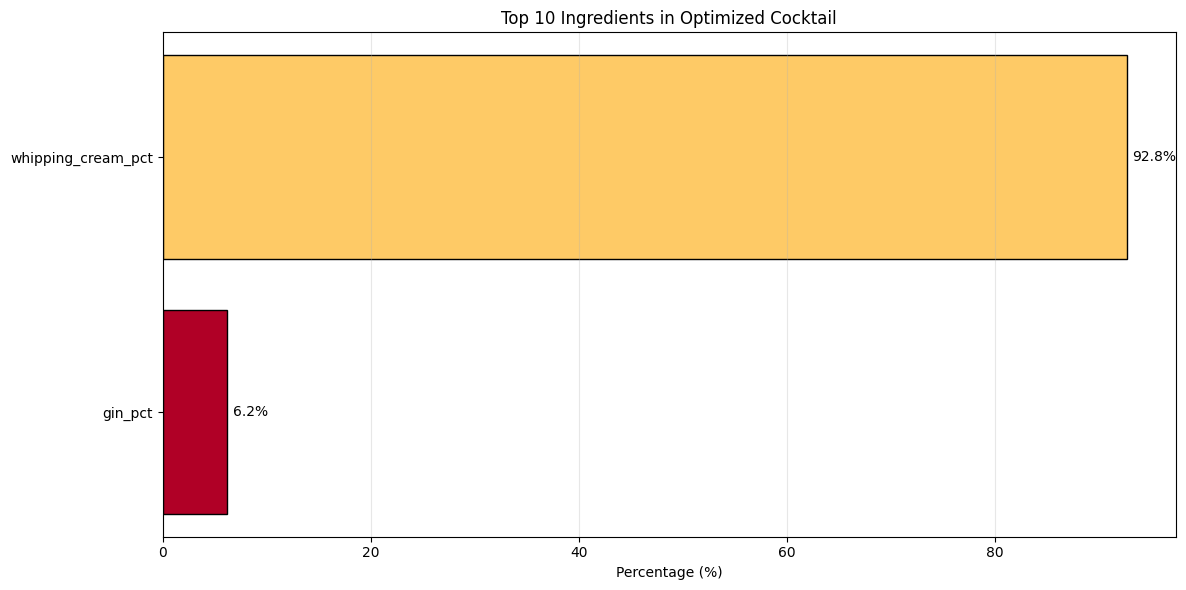


🧪 TEST 3: Complex - 'citrus', 'herbal', 'bittersweet' with vodka and lime
--------------------------------------------------------------------------------

COCKTAIL GENETIC ALGORITHM OPTIMIZATION

🎯 Target flavors: {'citrus': 0.4, 'herbal': 0.4, 'bittersweet': 0.2}
🔧 Mandatory ingredients: ['vodka_pct', 'lime_juice_pct']
👥 Initial population: 100 individuals
📊 Initial fitness - Min: 0.062, Avg: 0.336, Max: 0.576
   Generation   0: Avg fitness = 0.421, Best = 0.693
   Generation   5: Avg fitness = 0.618, Best = 0.725
   Generation  10: Avg fitness = 0.685, Best = 0.807
   Generation  15: Avg fitness = 0.786, Best = 0.839
   Generation  20: Avg fitness = 0.799, Best = 0.845
   Generation  25: Avg fitness = 0.820, Best = 0.846
   Generation  30: Avg fitness = 0.816, Best = 0.847
   Generation  35: Avg fitness = 0.797, Best = 0.848
   Generation  40: Avg fitness = 0.773, Best = 0.848
   Generation  45: Avg fitness = 0.811, Best = 0.848

✅ Optimization complete after 50 generations!
🏆 Best

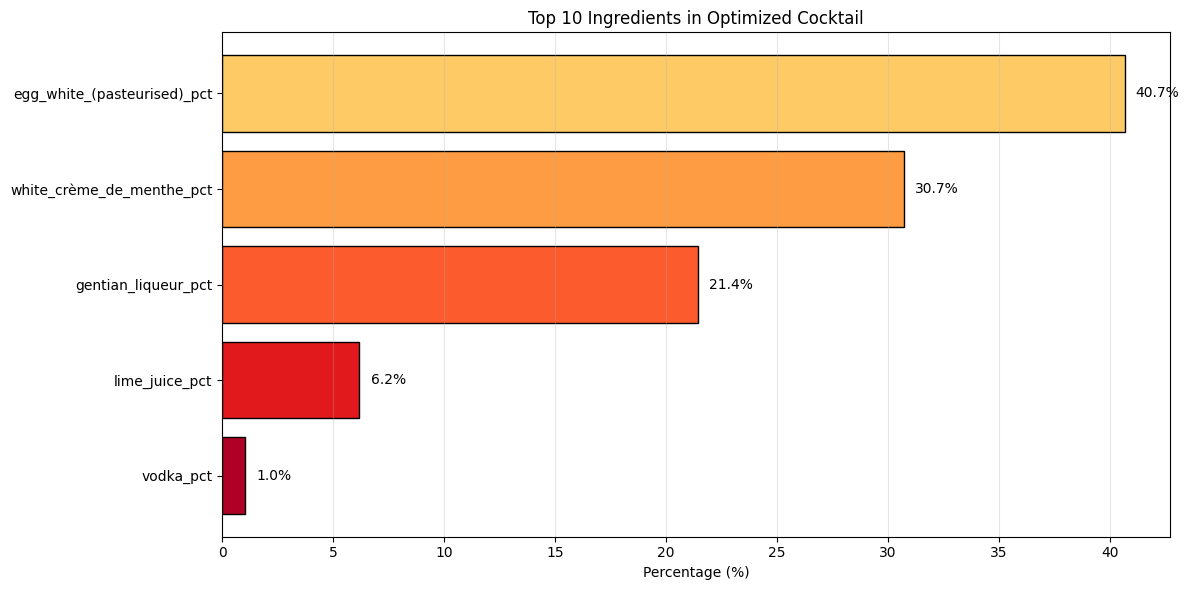

In [18]:
# Example 1: Simple single flavor optimization
print("\n🧪 TEST 1: Optimize for 'citrus' flavor")
print("-" * 80)

target_flavors_1 = {'citrus': 1.0}
best_recipe_1, logbook_1, hof_1 = run_cocktail_ga(
    target_flavors=target_flavors_1,
    mandatory_ingredients=None,
    verbose=True
)

analyze_individual(best_recipe_1, target_flavors_1)
# plot_evolution(logbook_1, target_flavors_1)
plot_cocktail_recipe(best_recipe_1)

# Example 2: Multi-flavor with mandatory ingredients
print("\n" + "=" * 80)
print("🧪 TEST 2: Optimize for 'sweet' and 'creamy' with gin as base")
print("-" * 80)

target_flavors_2 = {'sweet': 0.6, 'creamy': 0.4}
best_recipe_2, logbook_2, hof_2 = run_cocktail_ga(
    target_flavors=target_flavors_2,
    mandatory_ingredients=['gin_pct'],  # Must include gin
    verbose=True
)

analyze_individual(best_recipe_2, target_flavors_2)
# plot_evolution(logbook_2, target_flavors_2)
plot_cocktail_recipe(best_recipe_2)

# Example 3: Complex multi-flavor with multiple mandatory ingredients
print("\n" + "=" * 80)
print("🧪 TEST 3: Complex - 'citrus', 'herbal', 'bittersweet' with vodka and lime")
print("-" * 80)

target_flavors_3 = {'citrus': 0.4, 'herbal': 0.4, 'bittersweet': 0.2}
best_recipe_3, logbook_3, hof_3 = run_cocktail_ga(
    target_flavors=target_flavors_3,
    mandatory_ingredients=['vodka_pct', 'lime_juice_pct'],
    verbose=True
)

analyze_individual(best_recipe_3, target_flavors_3)
# plot_evolution(logbook_3, target_flavors_3)
plot_cocktail_recipe(best_recipe_3)

In [ ]:
# ============================================================================
# 4. DEAP SETUP FOR GENETIC ALGORITHM
# ============================================================================

print("\n" + "=" * 80)
print("4. SETTING UP GENETIC ALGORITHM WITH DEAP")
print("=" * 80)

# 4.1 Define fitness and individual types


# ============================================================================
# 5. GENETIC ALGORITHM EXECUTION FUNCTION
# ============================================================================



# ============================================================================
# 6. RESULT ANALYSIS AND VISUALIZATION FUNCTIONS
# ============================================================================


# ============================================================================
# 7. MAIN EXECUTION - TEST THE SYSTEM
# ============================================================================

print("\n" + "=" * 80)
print("7. TESTING THE COCKTAIL GENETIC ALGORITHM")
print("=" * 80)



# ============================================================================
# 8. SAVE OPTIMIZED MODELS AND RESULTS
# ============================================================================

print("\n" + "=" * 80)
print("8. SAVING OPTIMIZED RESULTS")
print("=" * 80)

# Save the best recipes
optimization_results = {
    'ga_config': GA_CONFIG,
    'ingredient_columns': ingredient_columns,
    'flavor_categories': flavor_categories,
    'optimal_thresholds': optimal_thresholds,
    'test_results': {
        'citrus_optimized': {
            'recipe': best_recipe_1,
            'fitness': best_recipe_1.fitness.values[0],
            'target_flavors': target_flavors_1
        },
        'sweet_creamy_optimized': {
            'recipe': best_recipe_2,
            'fitness': best_recipe_2.fitness.values[0],
            'target_flavors': target_flavors_2
        },
        'complex_optimized': {
            'recipe': best_recipe_3,
            'fitness': best_recipe_3.fitness.values[0],
            'target_flavors': target_flavors_3
        }
    },
    'hall_of_fame': {
        'citrus': [ind for ind in hof_1],
        'sweet_creamy': [ind for ind in hof_2],
        'complex': [ind for ind in hof_3]
    }
}

with open('cocktail_ga_results.pkl', 'wb') as f:
    pickle.dump(optimization_results, f)

print("✅ Results saved to 'cocktail_ga_results.pkl'")

# ============================================================================
# 9. PRODUCTION READY FUNCTION
# ============================================================================

def optimize_cocktail(target_flavors, mandatory_ingredients=None, 
                     mandatory_percentages=None, return_all=False):
    """
    Production-ready function to optimize cocktail recipe
    
    Parameters:
    -----------
    target_flavors: dict of {flavor: weight} 
    mandatory_ingredients: list of ingredient names
    mandatory_percentages: optional percentages for mandatory ingredients
    return_all: if True, return all results including hall of fame
    
    Returns:
    --------
    dict containing optimized recipe and analysis
    """
    print(f"\n🔍 Optimizing cocktail for: {target_flavors}")
    if mandatory_ingredients:
        print(f"   With mandatory ingredients: {mandatory_ingredients}")
    
    # Run GA
    best_recipe, logbook, hall_of_fame = run_cocktail_ga(
        target_flavors=target_flavors,
        mandatory_ingredients=mandatory_ingredients,
        mandatory_percentages=mandatory_percentages,
        verbose=False
    )
    
    # Analyze the recipe
    ingredient_vector = np.array(best_recipe)
    
    # Get active ingredients
    active_ingredients = []
    for idx, pct in enumerate(best_recipe):
        if pct > GA_CONFIG['MIN_INGREDIENT_PCT']:
            active_ingredients.append({
                'name': ingredient_columns[idx],
                'percentage': float(pct),
                'percentage_display': f"{pct*100:.2f}%"
            })
    
    # Sort by percentage
    active_ingredients.sort(key=lambda x: x['percentage'], reverse=True)
    
    # Calculate flavor probabilities
    flavor_scores = {}
    for flavor in target_flavors.keys():
        if flavor in taste_models:
            proba = taste_models[flavor]['model'].predict_proba(ingredient_vector.reshape(1, -1))[0][1]
            threshold = optimal_thresholds.get(flavor, 0.5)
            flavor_scores[flavor] = {
                'probability': float(proba),
                'threshold': float(threshold),
                'above_threshold': proba >= threshold
            }
    
    result = {
        'fitness': float(best_recipe.fitness.values[0]),
        'ingredients': active_ingredients,
        'flavor_scores': flavor_scores,
        'total_ingredients': len(active_ingredients),
        'total_percentage': float(sum(best_recipe)),
        'generations': GA_CONFIG['GENERATIONS']
    }
    
    if return_all:
        result.update({
            'logbook': logbook,
            'hall_of_fame': hall_of_fame,
            'best_individual': best_recipe
        })
    
    return result

# ============================================================================
# 10. EXAMPLE USAGE FOR PRODUCTION
# ============================================================================

print("\n" + "=" * 80)
print("10. PRODUCTION USAGE EXAMPLES")
print("=" * 80)

print("""
# Example 1: Simple citrus cocktail
result = optimize_cocktail(
    target_flavors={'citrus': 1.0},
    mandatory_ingredients=None
)

# Example 2: Sweet and creamy with gin base
result = optimize_cocktail(
    target_flavors={'sweet': 0.6, 'creamy': 0.4},
    mandatory_ingredients=['gin_pct']
)

# Example 3: Complex cocktail with specific base
result = optimize_cocktail(
    target_flavors={'citrus': 0.5, 'herbal': 0.3, 'bittersweet': 0.2},
    mandatory_ingredients=['vodka_pct', 'lime_juice_pct'],
    mandatory_percentages=[0.4, 0.2]  # Optional: specify percentages
)

# The result contains:
# - ingredients: List of ingredients with percentages
# - flavor_scores: How well it matches target flavors
# - fitness: Overall fitness score
# - total_ingredients: Number of active ingredients
""")

# Test the production function
print("\n🧪 Testing production function with custom request...")
test_result = optimize_cocktail(
    target_flavors={'citrus': 0.7, 'sweet': 0.3},
    mandatory_ingredients=['gin_pct']
)

print(f"\n✅ Optimized Recipe Found!")
print(f"   Fitness score: {test_result['fitness']:.3f}")
print(f"   Total ingredients: {test_result['total_ingredients']}")
print(f"   Flavor scores:")
for flavor, scores in test_result['flavor_scores'].items():
    status = "✓" if scores['above_threshold'] else "✗"
    print(f"     {flavor}: {scores['probability']:.3f} {status}")

print("\n🍹 Top 5 ingredients:")
for i, ing in enumerate(test_result['ingredients'][:5], 1):
    print(f"   {i}. {ing['name']}: {ing['percentage_display']}")

print("\n" + "=" * 80)
print("✅ COCKTAIL GENETIC ALGORITHM READY FOR PRODUCTION!")
print("=" * 80)